In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [49]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cogwheel.data
from cogwheel import gw_plotting, utils, gw_utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
# from generate_injection_params import generate_injection_parameters
from helpers import load_event_data_and_posterior_samples, add_derived_quantities_injection

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"
warnings.simplefilter("ignore", RuntimeWarning)

### get injection parameters

In [3]:
approximant = 'IMRPhenomXPHM'
save_fn = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/injection_params_{approximant}.pkl'

# I used the following code to generate the injection parameters:
# injection_params = generate_injection_parameters(100, approximant)
# save_fn = f'/home/abbye.williams/GWPE/data/injections/injection_params_{approximant}.pkl'
# injection_params.to_pickle(save_fn)

# load the injection parameters:
injection_params = pd.read_pickle(save_fn)

Text(0.5, 0.97, 'Injection parameters (Halton)')

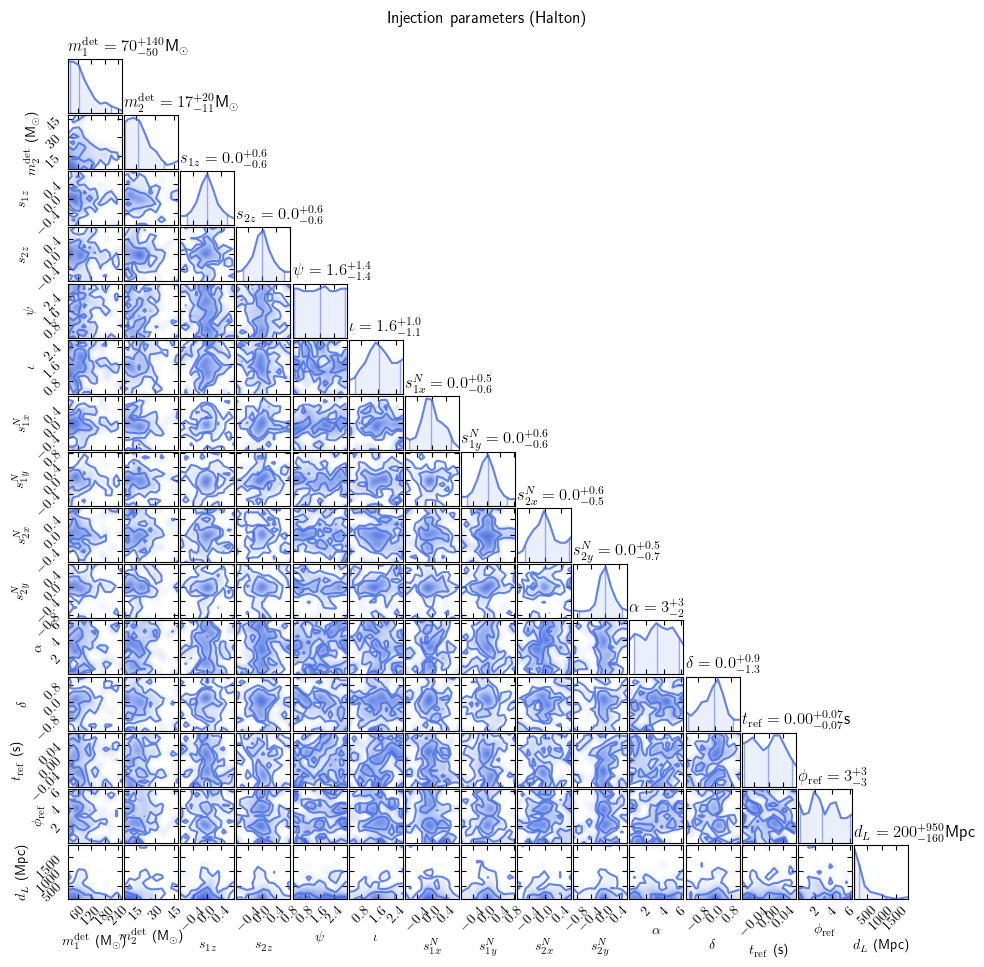

In [4]:
# do these look reasonable?
params_to_plot = injection_params.columns.to_list()
for par_id in ['f_ref', 'l1', 'l2']:
    params_to_plot.remove(par_id)
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
cp = gw_plotting.CornerPlot(injection_params, params_to_plot, **corner_plot_kwargs)
cp.plot()
cp.fig.suptitle('Injection parameters (Halton)', y=0.97)


### PE results

In [5]:
# get the SNR and compute the Bayes factor
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
nevents = 100
idx_existing = []
idx_to_run = []
n_resamples = 1000
h_h = {}
d_h = {}
lnBayes = {}
# parameters to collect
params = {}
for idx in range(nevents):
    # load this sample
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = load_event_data_and_posterior_samples(eventdir, eventname)
        samples['cosiota'] = np.cos(samples['iota'])    # add mu = cos(iota) to plot
        idx_existing.append(idx)
    except FileNotFoundError:
        print(f"no samples for idx {idx}. continuing")
        idx_to_run.append(idx)
        continue

    # add derived quantities to the injection dictionary
    injection_dic = event_data.get_init_dict()['injection']
    injected_par_dic = injection_dic['par_dic']
    add_derived_quantities_injection(injected_par_dic)
    injected_par_dic['cosiota'] = np.cos(injected_par_dic['iota'])

    # optimal SNR: inner product from the injection
    h_h[idx] = np.sum(injection_dic['h_h'])
    d_h[idx] = np.sum(injection_dic['d_h'])

    # Bayes factor
    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    try:
        lnBayes[idx] = np.load(lnBayes_fn)
    except FileNotFoundError:
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnBayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnBayes[idx] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
        np.save(lnBayes_fn, lnBayes[idx])

    # median from the posterior
    for par_id, injected_value in injected_par_dic.items():
        median_post = utils.quantile(samples[par_id], 0.5, weights=samples['weights'])
        try:
            params[par_id][idx] = (injected_value, median_post)
        except KeyError:    # if the dictionary doesn't exist yet
            params[par_id] = {}
            params[par_id][idx] = (injected_value, median_post)

no samples for idx 0. continuing
loaded posterior samples for GW12_1 run 0
loaded posterior samples for GW12_2 run 0
loaded posterior samples for GW12_3 run 0
loaded posterior samples for GW12_4 run 0
loaded posterior samples for GW12_5 run 0
loaded posterior samples for GW12_6 run 0
loaded posterior samples for GW12_7 run 0
loaded posterior samples for GW12_8 run 0
loaded posterior samples for GW12_9 run 0
loaded posterior samples for GW12_10 run 0
loaded posterior samples for GW12_11 run 0
loaded posterior samples for GW12_12 run 0
loaded posterior samples for GW12_13 run 0
loaded posterior samples for GW12_14 run 0
loaded posterior samples for GW12_15 run 0
loaded posterior samples for GW12_16 run 0
no samples for idx 17. continuing
loaded posterior samples for GW12_18 run 0
no samples for idx 19. continuing
loaded posterior samples for GW12_20 run 0
loaded posterior samples for GW12_21 run 0
loaded posterior samples for GW12_22 run 0


loaded posterior samples for GW12_23 run 0
loaded posterior samples for GW12_24 run 0
loaded posterior samples for GW12_25 run 0
no samples for idx 26. continuing
loaded posterior samples for GW12_27 run 0
loaded posterior samples for GW12_28 run 0
loaded posterior samples for GW12_29 run 0
loaded posterior samples for GW12_30 run 0
loaded posterior samples for GW12_31 run 0
loaded posterior samples for GW12_32 run 0
loaded posterior samples for GW12_33 run 0
loaded posterior samples for GW12_34 run 0
loaded posterior samples for GW12_35 run 0
loaded posterior samples for GW12_36 run 0
loaded posterior samples for GW12_37 run 0
loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_39 run 0
no samples for idx 40. continuing
loaded posterior samples for GW12_41 run 0
loaded posterior samples for GW12_42 run 0
loaded posterior samples for GW12_43 run 0
loaded posterior samples for GW12_44 run 0
loaded posterior samples for GW12_45 run 0
no samples for idx 46. contin

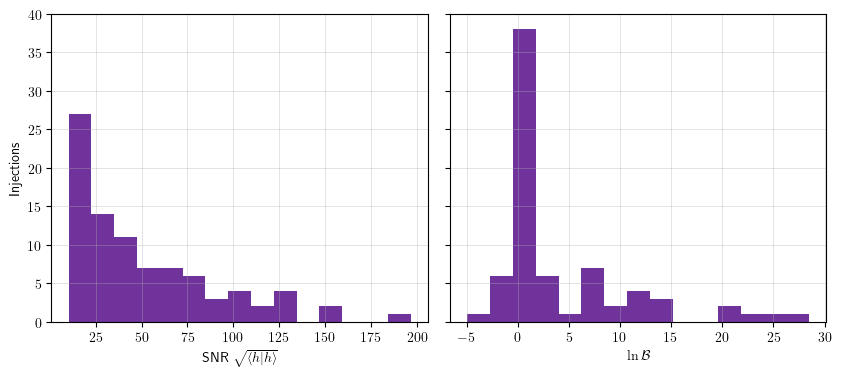

In [6]:
# distribution of SNR and Bayes factors
fig, axs = plt.subplots(1, 2, figsize=(10,4), gridspec_kw=dict(wspace=0.06))
snr = np.sqrt(list(h_h.values()))
lnBayes_grid = np.array([
    x[0] for x in lnBayes.values()
])
bins = 15
for ax, vals in zip(axs, [snr, lnBayes_grid]):
    _, _, _ = ax.hist(vals, color='indigo', lw=2, alpha=0.8, bins=bins)
    ax.grid(alpha=0.5, lw=0.5)
    ax.set_ylim(0., 40)
axs[1].set_xlabel(r'$\ln\mathcal B$')
axs[0].set_xlabel(r'SNR $\sqrt{\langle h|h\rangle}$')
axs[0].set_ylabel('Injections')
_ = axs[1].set_yticklabels([])

Text(0, 0.5, 'Injections')

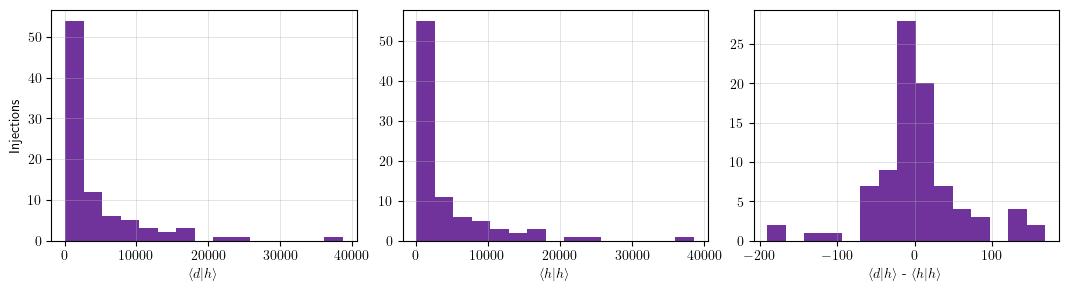

In [7]:
# difference between dh and hh
dh_list = list(d_h.values())
hh_list = list(h_h.values())
res = np.array(dh_list) - np.array(hh_list)
fig, axs = plt.subplots(1, 3, figsize=(13,3), gridspec_kw=dict(wspace=0.15))
bins = 15
xlabels = [r"$\langle d|h\rangle$", r"$\langle h|h\rangle$", r"$\langle d|h\rangle$ - $\langle h|h\rangle$"]
for ax, vals, xlabel in zip(axs, [dh_list, hh_list, res], xlabels):
    _, _, _ = ax.hist(vals, color='indigo', alpha=0.8, bins=bins)
    ax.grid(alpha=0.5, lw=0.5)
    ax.set_xlabel(xlabel)
axs[0].set_ylabel('Injections')

In [8]:
# plot parameters
s = np.array([h_h[k] for k in idx_existing])
c = np.array([lnBayes[k][0] for k in idx_existing])

# sort the events in order of increasing SNR, so the larger markers don't cover up the smaller ones when we plot
idx_sorted = np.argsort(s)[::-1]
s = s[idx_sorted]
c = c[idx_sorted]

# some of these ln B are actually NaN
idx_lnB_nan = np.isnan(c)
print(f"{idx_lnB_nan.sum()} injections have lnB = NaN")
plot_kwargs = dict(c=c, ec='k', lw=0.5, s=s / 12, alpha=0.9, cmap=sns.color_palette('Blues', as_cmap=True))

15 injections have lnB = NaN


/local/abbye.williams/ipykernel_2660095/190895333.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(injected[idx_lnB_nan], medians[idx_lnB_nan],


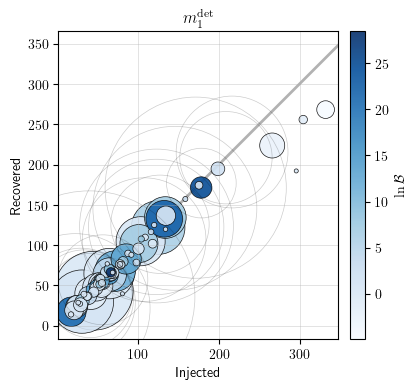

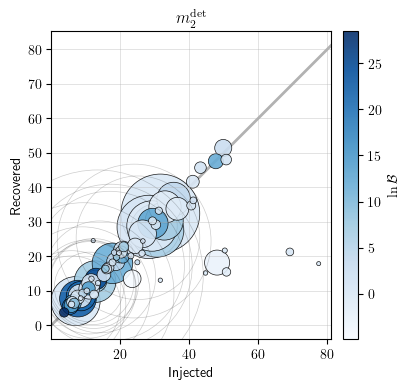

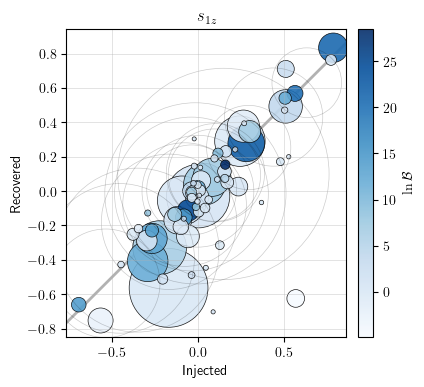

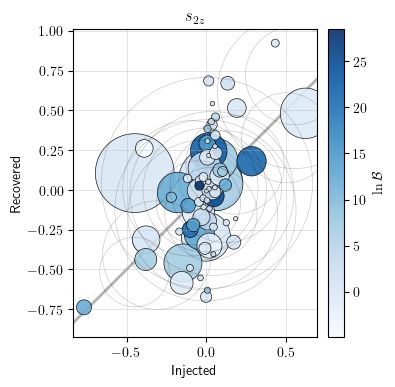

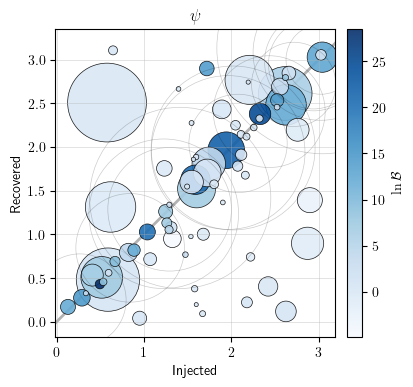

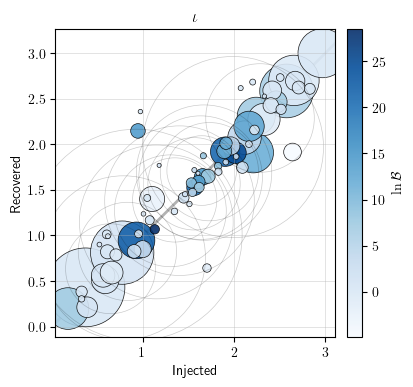

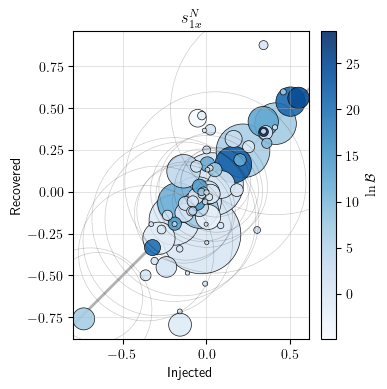

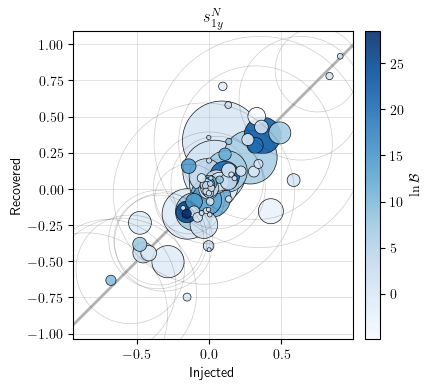

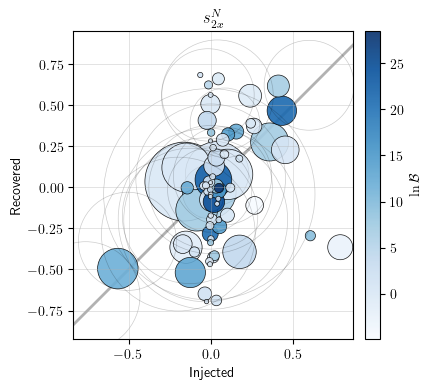

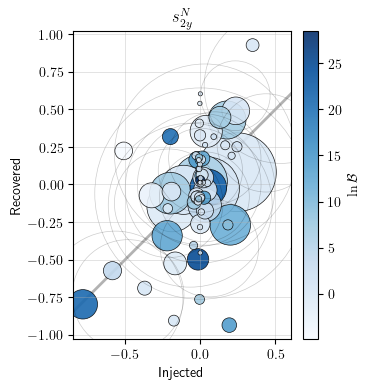

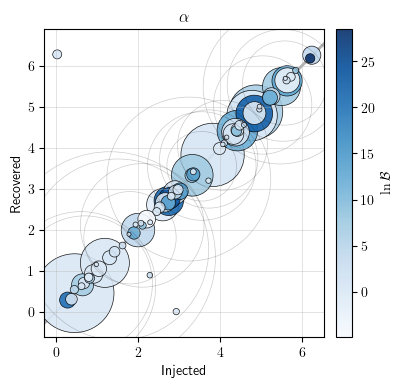

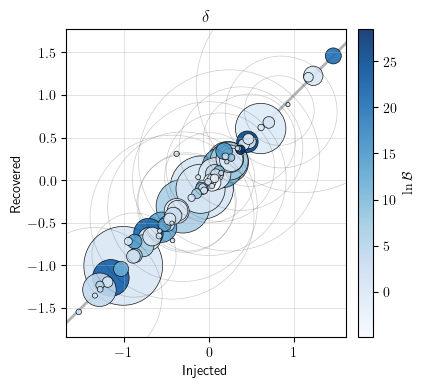

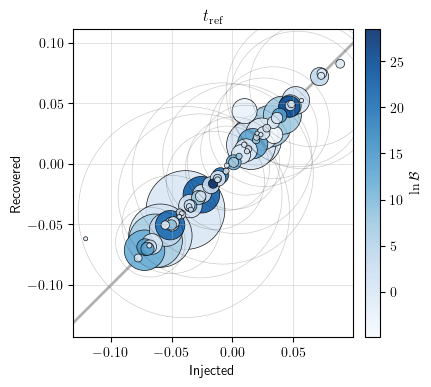

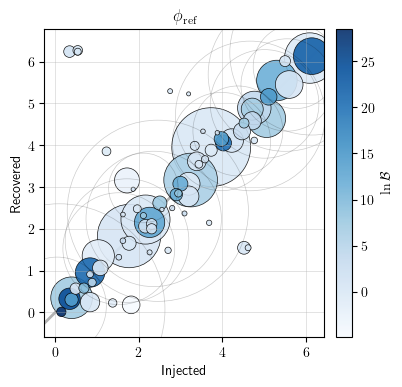

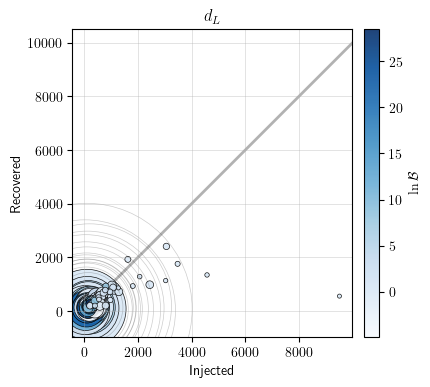

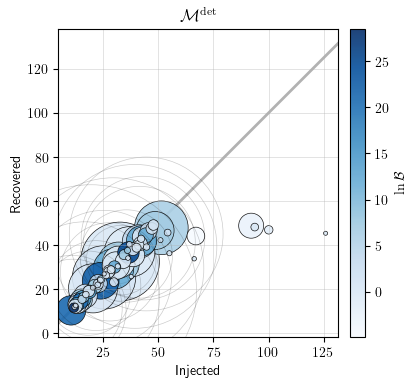

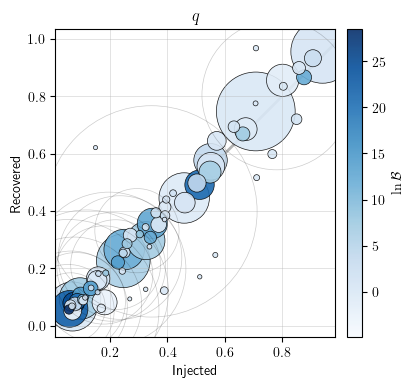

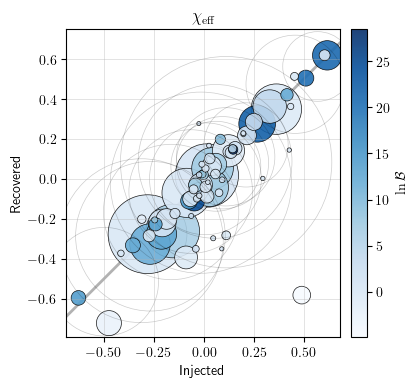

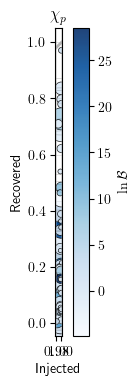

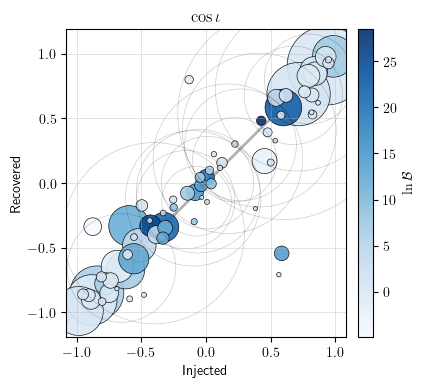

In [9]:
# let's scatter the injected vs recovered
for par_id, par_dict in params.items():
    if par_id in ['f_ref', 'l1', 'l2']:
        continue
    medians, injected = np.array(list(par_dict.values()))[idx_sorted].T
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.scatter(injected, medians, **plot_kwargs)
    ax.scatter(injected[idx_lnB_nan], medians[idx_lnB_nan],
                **plot_kwargs | dict(c='None', s=s[idx_lnB_nan], alpha=0.2))
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, alpha=0.3, c='k', lw=2, zorder=0)
    ax.set_xlim(xlim)
    ax.set_xlabel('Injected')
    ax.set_ylabel('Recovered')
    try:
        ax.set_title(gw_plotting._LABELS[par_id])
    except KeyError:
        ax.set_title(par_id)
    ax.grid(alpha=0.5, lw=0.5)
    fig.colorbar(im, ax=ax, pad=0.03, label=r'$\ln\mathcal B$')#r'SNR $\rho^2$')
    ax.set_aspect('equal')

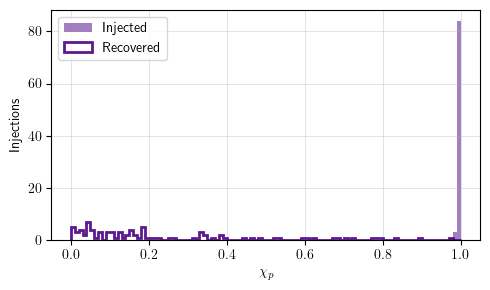

In [11]:
# injected chi_p distribution
fig, ax = plt.subplots(figsize=(5,3), tight_layout=True)
medians, injected = np.array(list(params['chip'].values()))[idx_sorted].T
bins = np.linspace(0., 1., 101)
_, _, _ = ax.hist(injected, color='indigo', lw=2, alpha=0.5, bins=bins, label='Injected')
_, _, _ = ax.hist(medians, color='indigo', histtype='step', lw=2, alpha=0.9, bins=bins, label='Recovered')
ax.grid(alpha=0.5, lw=0.5)
ax.set_xlabel(r'$\chi_p$')
ax.set_ylabel('Injections')
ax.legend()

In [12]:
# wrap the iotas
medians, injected = np.array(list(params['iota'].values()))[idx_sorted].T
rec_iotas_wrapped = np.array([
    np.min([iota, np.pi - iota]) for iota in medians.flatten()
])
inj_iotas_wrapped = np.array([
    np.min([iota, np.pi - iota]) for iota in injected.flatten()
])

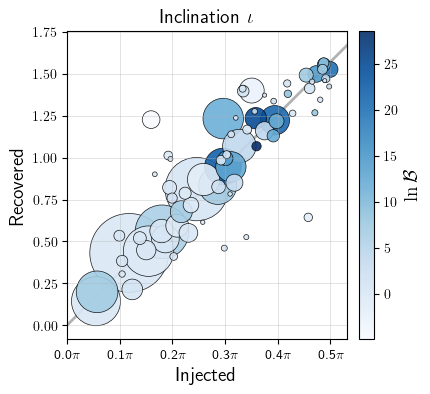

In [13]:
fig, ax = plt.subplots(figsize=(5,4))
im = ax.scatter(inj_iotas_wrapped, rec_iotas_wrapped, **plot_kwargs)
xlim = (0., np.pi / 2 + 0.1)
xticks = np.arange(0., 0.51, 0.1) * np.pi
xticklabels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]
ax.plot(xlim, xlim, alpha=0.3, c='k', lw=2, zorder=0)
ax.set_xlim(xlim)
ax.set_xticks(xticks, labels=xticklabels)
ax.set_xlabel(r'Injected', fontsize=14)
ax.set_ylabel(r'Recovered', fontsize=14)
ax.set_title(r'Inclination $\iota$', fontsize=14)
ax.grid(alpha=0.5, lw=0.5)
cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label(r'$\ln\mathcal B$', fontsize=14)
ax.set_aspect('equal')

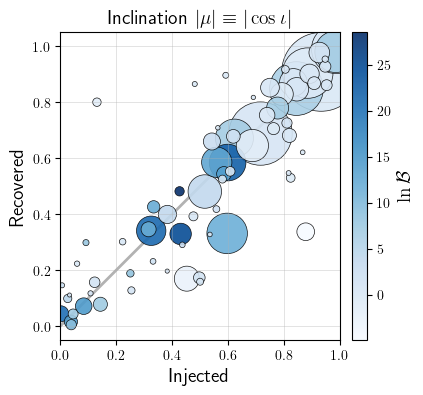

In [40]:
mu_medians, mu_injected = np.array(list(params['cosiota'].values()))[idx_sorted].T
fig, ax = plt.subplots(figsize=(5,4))
im = ax.scatter(np.abs(mu_injected), np.abs(mu_medians), **plot_kwargs)
xlim = (0., 1.)
# xticks = np.arange(0., 0.51, 0.1) * np.pi
# xticklabels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]
ax.plot(xlim, xlim, alpha=0.3, c='k', lw=2, zorder=0)
ax.set_xlim(xlim)
# ax.set_xticks(xticks, labels=xticklabels)
ax.set_xlabel(r'Injected', fontsize=14)
ax.set_ylabel(r'Recovered', fontsize=14)
ax.set_title(r'Inclination $|\mu|\equiv|\cos\iota|$', fontsize=14)
ax.grid(alpha=0.5, lw=0.5)
cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label(r'$\ln\mathcal B$', fontsize=14)
ax.set_aspect('equal')

In [30]:
np.isnan(c).sum()

np.int64(15)

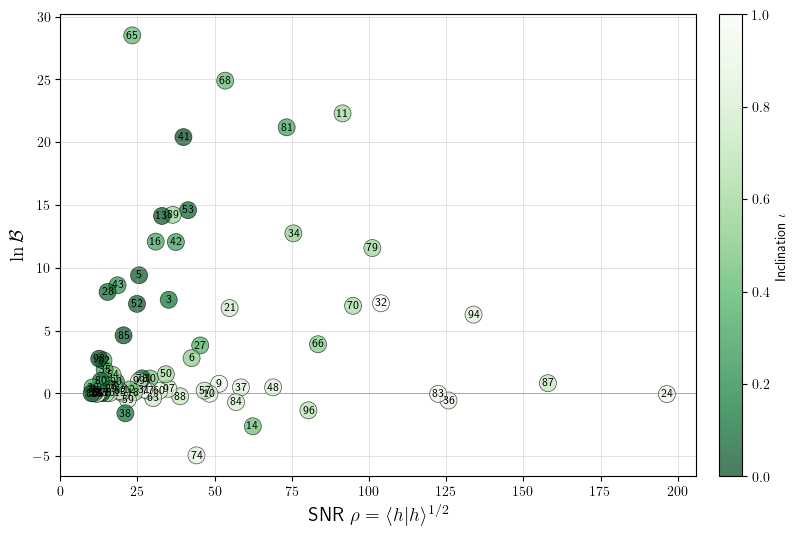

In [58]:
# SNR vs ln B
fig, ax = plt.subplots(figsize=(10,6), gridspec_kw=dict(wspace=0.06))
par_id = 'cosiota'
colors = np.array([
    np.abs(x[1]) for x in params[par_id].values()
])[idx_sorted]
inj_idx_sorted = np.array(list(lnBayes.keys()))[idx_sorted]
im = ax.scatter(np.sqrt(s), c, c=colors, ec='k', lw=0.5, marker='o', s=150, alpha=0.7,
                cmap=sns.color_palette('Greens_r', as_cmap=True), vmin=0., vmax=1.)
for i, inj_idx in enumerate(inj_idx_sorted):
    if ~np.isnan(c[i]):
        ax.text(np.sqrt(s[i]), c[i], str(inj_idx), fontsize=8,
                verticalalignment='center', horizontalalignment='center')
ax.axhline(0., c='k', alpha=0.5, lw=0.5, zorder=0)
ax.set_xlim(0., None)
ax.set_xlabel(r'SNR $\rho=\langle h|h\rangle^{1/2}$', fontsize=14)
ax.set_ylabel(r'$\ln\mathcal B$', fontsize=14)
ax.grid(alpha=0.5, lw=0.5)
fig.colorbar(im, ax=ax, pad=0.03, label=r'Inclination $\iota$')

In [39]:
# let's investigate to double check that the inclinations match the correct points
# the first event in our sorted array s has the highest SNR:
i_sorted = 0
labels = ['SNR sq', 'lnB', 'iota']
print(f"this injection has")
for label, arr in zip(labels, [s, c, colors]):
    print(f"{label:<6}:{arr[i_sorted]:>12.3f}")
# do these values match the results that we directly loaded?
# find the original event index
i_orig = idx_sorted[i_sorted]
h_h_grid = list(h_h.values())
_, inj_iotas = np.array(list(params['iota'].values())).T
for label, arr in zip(labels, [h_h_grid, lnBayes_grid, inj_iotas]):
    print(f"{label:<6}:{arr[i_orig]:>12.3f}")

this injection has
SNR sq:   38613.956
lnB   :      -0.065
iota  :       0.371
SNR sq:   38613.956
lnB   :      -0.065
iota  :       0.371


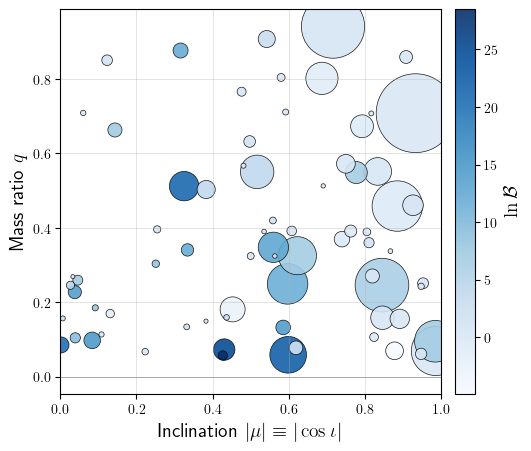

In [42]:
# iota vs q
fig, ax = plt.subplots(figsize=(6,5))
medians_q, injected_q = np.array(list(params['q'].values()))[idx_sorted].T
im = ax.scatter(np.abs(mu_injected), injected_q, **plot_kwargs)
ax.axhline(0., c='k', alpha=0.5, lw=0.5, zorder=0)
xlim = (0., 1.)
# xticks = np.arange(0., 0.51, 0.1) * np.pi
# xticklabels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]
ax.set_xlim(xlim)
# ax.set_xticks(xticks, labels=xticklabels)
ax.set_xlabel(r'Inclination $|\mu|\equiv|\cos\iota|$', fontsize=14)
ax.set_ylabel(r'Mass ratio $q$', fontsize=14)
ax.grid(alpha=0.5, lw=0.5)
cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label(r'$\ln\mathcal B$', fontsize=14)

In [17]:
# compute the mismatch quantity (this will be already sorted by SNR)
mismatch = c / s

Text(0.45, 0.93, 'Injections')

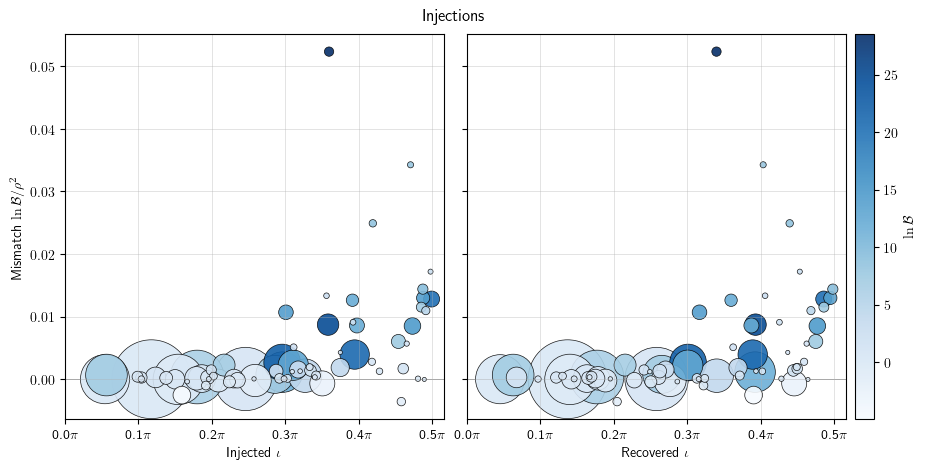

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), gridspec_kw=dict(wspace=0.06))
xticks = np.arange(0., 0.51, 0.1) * np.pi
xticklabels = [f'{x / np.pi:.1f}'+r'$\pi$' for x in xticks]
for (ax, iotas, label) in zip(axs, [inj_iotas_wrapped, rec_iotas_wrapped], ['Injected', 'Recovered']):
    im = ax.scatter(iotas, mismatch, **plot_kwargs)
    ax.axhline(0., c='k', alpha=0.5, lw=0.5, zorder=0)
    ax.set_xlabel(label + r' $\iota$')
    ax.set_xticks(xticks, labels=xticklabels)
    ax.set_xlim(0., np.pi/2 + 0.05)
    ax.grid(alpha=0.5, lw=0.5)
axs[0].set_ylabel(r'Mismatch $\ln\mathcal B/\rho^2$')
axs[1].set_yticklabels([])
fig.colorbar(im, ax=axs, label=r'$\ln\mathcal B$', pad=0.01)
fig.suptitle(r'Injections', x=0.45, y=0.93)

Text(0.45, 0.93, 'Injections')

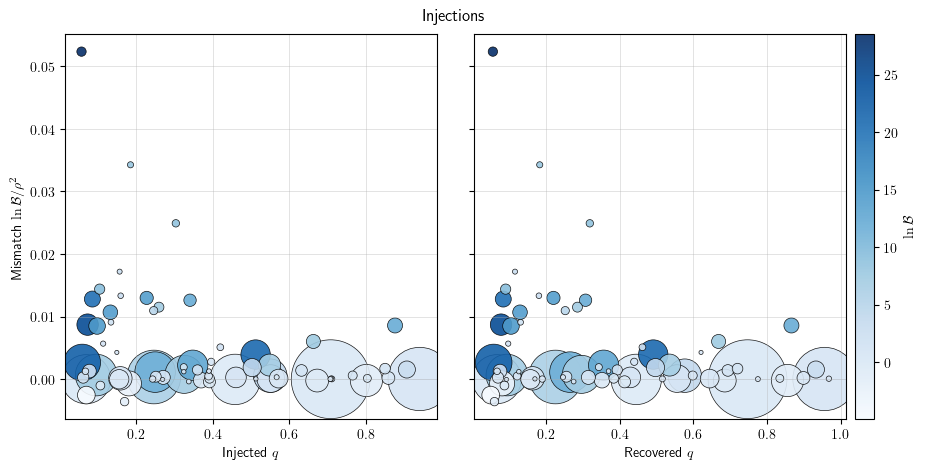

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), gridspec_kw=dict(wspace=0.1))
par_id = 'q'
unit = ''
rec_par, inj_par = np.array(list(params[par_id].values()))[idx_sorted].T
par_id_label = gw_plotting._LABELS[par_id] + unit
for (ax, par, label) in zip(axs, [inj_par, rec_par], ['Injected', 'Recovered']):
    im = ax.scatter(par, mismatch, **plot_kwargs)
    ax.axhline(0., c='k', alpha=0.5, lw=0.5, zorder=0)
    ax.set_xlabel(label+' '+par_id_label)
    # ax.set_xticks(xticks, labels=xticklabels)
    # ax.set_xlim(0., 4800)
    ax.grid(alpha=0.5, lw=0.5)
axs[0].set_ylabel(r'Mismatch $\ln\mathcal B/\rho^2$')
axs[1].set_yticklabels([])
fig.colorbar(im, ax=axs, label=r'$\ln\mathcal B$', pad=0.01)
fig.suptitle(r'Injections', x=0.45, y=0.93)

### corner plot: correlations with $\ln\mathcal B$

In [20]:
injected_params_df = injection_params.copy().drop(columns=['f_ref', 'l1', 'l2'])
# keep only the existing samples
injected_params_df = injected_params_df.iloc[idx_existing]
# then add the ln Bayes
lnB_arr = np.array([x[0] for x in lnBayes.values()])
injected_params_df.insert(0, 'lnBayes', lnB_arr)

Text(0.5, 0.97, 'Injection parameters (Halton)')

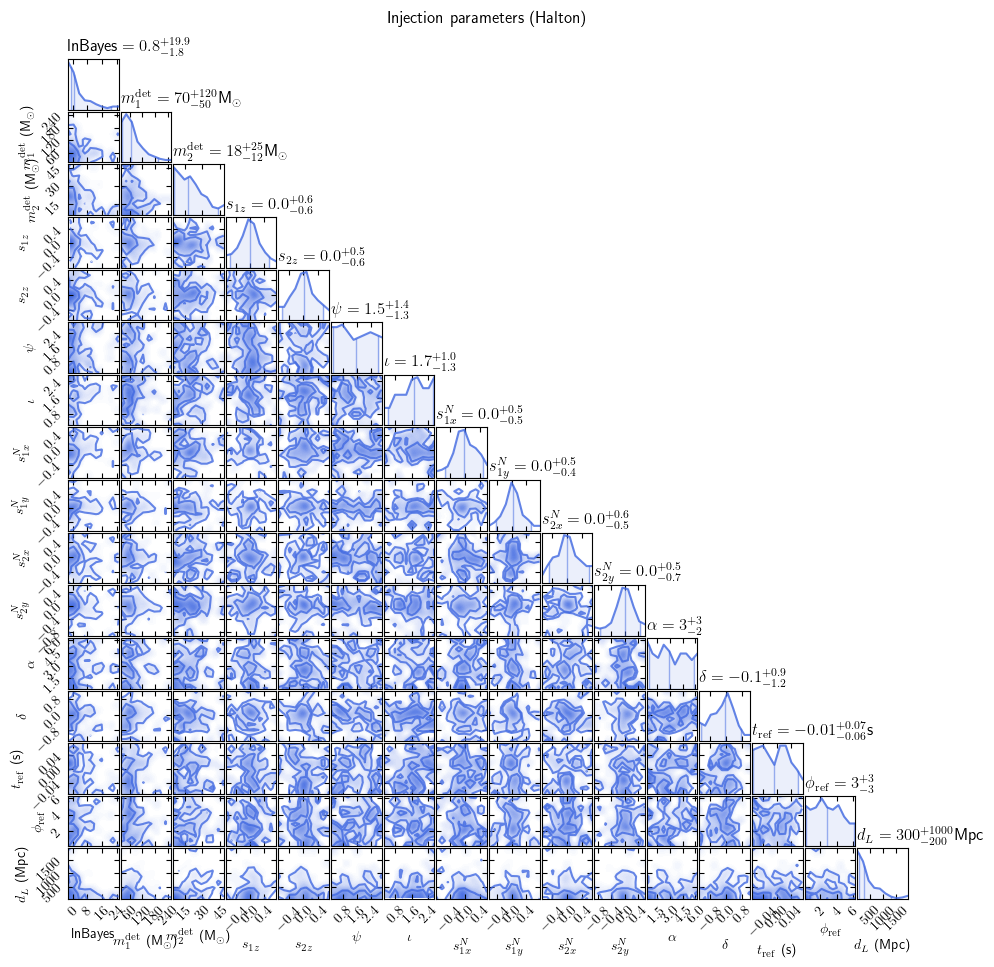

In [21]:
# do these look reasonable?
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
cp = gw_plotting.CornerPlot(injected_params_df, **corner_plot_kwargs)
cp.plot()
cp.fig.suptitle('Injection parameters (Halton)', y=0.97)

### investigate individual injections?

In [50]:
seed = 12
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'

In [52]:
idx = 32
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
ed = cogwheel.data.EventData.from_npz(os.path.join(eventdir, 'run_0', eventname))
# injected parameters
print(eventname+f'\n'+'=' * 35)
for key, value in ed.injection['par_dic'].items():
    print(f"{key:<18}:{value:>16.3f}")

GW12_32
f_ref             :         100.000
m1                :         134.179
m2                :          12.635
s1z               :           0.040
s2z               :           0.191
psi               :           0.508
iota              :           0.199
s1x_n             :           0.407
s1y_n             :           0.121
s2x_n             :          -0.139
s2y_n             :          -0.058
ra                :           3.325
dec               :           0.209
t_geocenter       :           0.031
phi_ref           :           0.351
d_luminosity      :         148.649
l1                :           0.000
l2                :           0.000


In [60]:
idx = 14
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
ed = cogwheel.data.EventData.from_npz(os.path.join(eventdir, 'run_0', eventname))
# injected parameters
print(eventname+f'\n'+'=' * 35)
for key, value in ed.injection['par_dic'].items():
    print(f"{key:<18}:{value:>16.3f}")

GW12_14
f_ref             :         100.000
m1                :         223.594
m2                :          18.160
s1z               :          -0.753
s2z               :          -0.350
psi               :           1.391
iota              :           1.400
s1x_n             :          -0.151
s1y_n             :          -0.154
s2x_n             :          -0.365
s2y_n             :          -0.072
ra                :           5.640
dec               :          -0.363
t_geocenter       :           0.043
phi_ref           :           3.157
d_luminosity      :          90.513
l1                :           0.000
l2                :           0.000


In [61]:
idx = 74
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
ed = cogwheel.data.EventData.from_npz(os.path.join(eventdir, 'run_0', eventname))
# injected parameters
print(eventname+f'\n'+'=' * 35)
for key, value in ed.injection['par_dic'].items():
    print(f"{key:<18}:{value:>16.3f}")

GW12_74
f_ref             :         100.000
m1                :         268.142
m2                :          13.465
s1z               :          -0.625
s2z               :           0.261
psi               :           0.950
iota              :           1.915
s1x_n             :           0.439
s1y_n             :           0.502
s2x_n             :          -0.110
s2y_n             :           0.223
ra                :           2.256
dec               :          -0.025
t_geocenter       :           0.024
phi_ref           :           0.182
d_luminosity      :          77.173
l1                :           0.000
l2                :           0.000
